In [1]:
import sys
sys.path.append("..")

from src.data import fetch_prices, compute_returns, compute_rolling_volatility
from src.regime import build_hmm_features, fit_hmm, label_regimes, plot_regimes
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices = fetch_prices()
returns = compute_returns(prices)
print("Price shape:", prices.shape)
print("Returns shape:", returns.shape)

[*********************100%***********************]  10 of 10 completed

Price shape: (2842, 10)
Returns shape: (2841, 10)


In [3]:
ew_return = returns.mean(axis=1)
ew_price = (1 + ew_return).cumprod()  

In [4]:
features = build_hmm_features(ew_return)
model, hidden_states = fit_hmm(features, n_states=4)

In [5]:
regime_series, label_map = label_regimes(model, hidden_states, features)
print("\nRegime distribution:")
print(regime_series.value_counts())


Regime distribution:
regime
Bull           1098
High-Vol        898
Neutral         720
Bear/Crisis     105
Name: count, dtype: int64


In [6]:
print("\nSample regimes around COVID crash:")
print(regime_series["2020-01":"2020-06"])


Sample regimes around COVID crash:
Date
2020-01-01       Bull
2020-01-02       Bull
2020-01-03       Bull
2020-01-06       Bull
2020-01-07       Bull
               ...   
2020-06-24    Neutral
2020-06-25    Neutral
2020-06-26    Neutral
2020-06-29    Neutral
2020-06-30    Neutral
Name: regime, Length: 122, dtype: str


In [7]:
print("ew_price:", ew_price.shape, ew_price.index.min(), ew_price.index.max())
print("regime_series:", regime_series.shape, regime_series.index.min(), regime_series.index.max())
print(ew_price.head())
print(regime_series.head())

ew_price: (2841,) 2015-01-02 00:00:00 2026-07-03 00:00:00
regime_series: (2821,) 2015-02-02 00:00:00 2026-07-03 00:00:00
Date
2015-01-02    1.007823
2015-01-05    1.006640
2015-01-06    0.981066
2015-01-07    0.980836
2015-01-08    0.990754
dtype: float64
Date
2015-02-02    High-Vol
2015-02-03    High-Vol
2015-02-04    High-Vol
2015-02-05    High-Vol
2015-02-06    High-Vol
Name: regime, dtype: str


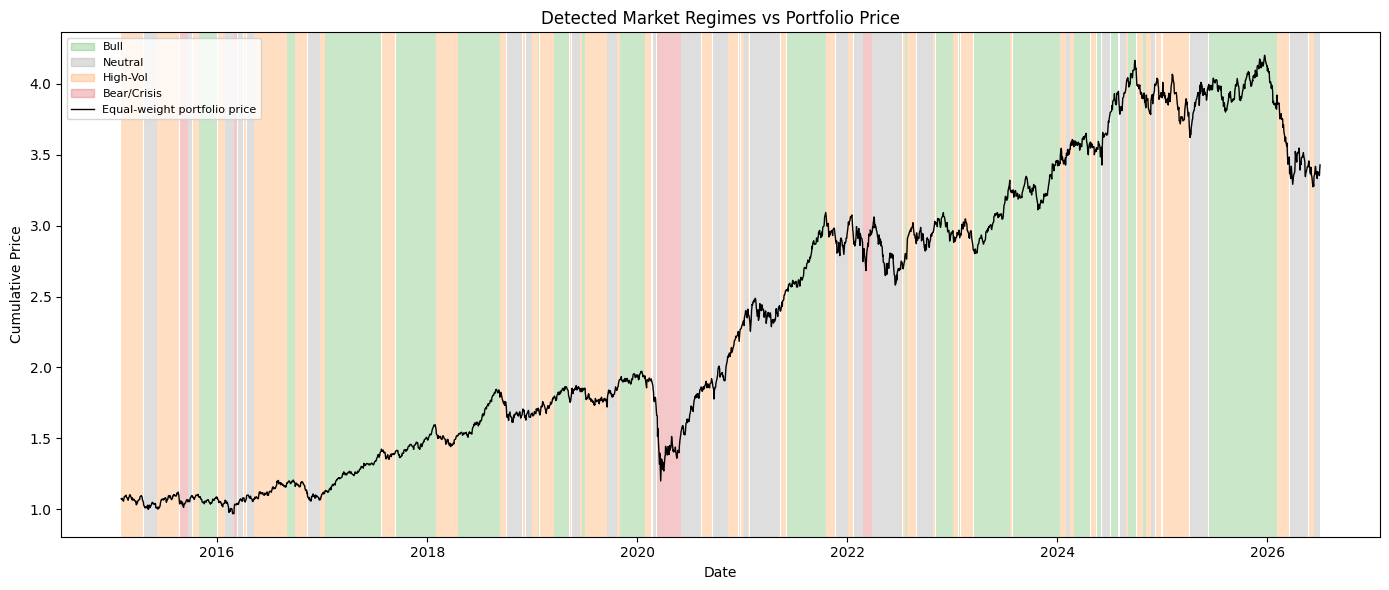

Plot saved to D:\quantrisk\data\regime_plot.png


In [8]:
plot_regimes(ew_price, regime_series)

In [9]:
from src.data import fetch_prices

prices = fetch_prices()
print(prices.shape)
print(prices.columns)

[*********************100%***********************]  10 of 10 completed

(2842, 10)
Index(['BAJFINANCE.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'ITC.NS',
       'MARUTI.NS', 'RELIANCE.NS', 'SUNPHARMA.NS', 'TCS.NS', 'WIPRO.NS'],
      dtype='str', name='Ticker')


In [10]:
print(regime_series["2020-03"])

Date
2020-03-02        Neutral
2020-03-03        Neutral
2020-03-04        Neutral
2020-03-05        Neutral
2020-03-06        Neutral
2020-03-09    Bear/Crisis
2020-03-11    Bear/Crisis
2020-03-12    Bear/Crisis
2020-03-13    Bear/Crisis
2020-03-16    Bear/Crisis
2020-03-17    Bear/Crisis
2020-03-18    Bear/Crisis
2020-03-19    Bear/Crisis
2020-03-20    Bear/Crisis
2020-03-23    Bear/Crisis
2020-03-24    Bear/Crisis
2020-03-25    Bear/Crisis
2020-03-26    Bear/Crisis
2020-03-27    Bear/Crisis
2020-03-30    Bear/Crisis
2020-03-31    Bear/Crisis
Name: regime, dtype: str


In [11]:
regime_series.groupby(regime_series.dt.year if hasattr(regime_series, 'dt') else regime_series.index.year).value_counts(normalize=True)

Date  regime     
2015  High-Vol       0.537778
      Neutral        0.186667
      Bull           0.182222
      Bear/Crisis    0.093333
2016  High-Vol       0.565041
      Neutral        0.329268
      Bull           0.073171
      Bear/Crisis    0.032520
2017  Bull           0.842742
      High-Vol       0.157258
2018  Bull           0.504065
      High-Vol       0.284553
      Neutral        0.211382
2019  High-Vol       0.477366
      Bull           0.349794
      Neutral        0.172840
2020  Neutral        0.406375
      High-Vol       0.290837
      Bear/Crisis    0.219124
      Bull           0.083665
2021  Neutral        0.439516
      Bull           0.375000
      High-Vol       0.185484
2022  Neutral        0.540323
      High-Vol       0.193548
      Bull           0.181452
      Bear/Crisis    0.084677
2023  Bull           0.795918
      High-Vol       0.204082
2024  Bull           0.422764
      High-Vol       0.345528
      Neutral        0.231707
2025  Bull           0

In [12]:
print(regime_series.value_counts(normalize=True))

regime
Bull           0.389224
High-Vol       0.318327
Neutral        0.255229
Bear/Crisis    0.037221
Name: proportion, dtype: float64
